### Import Libraries 

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from wordcloud import WordCloud
from collections import Counter
import re

In [3]:
sns.set_theme(
    rc={'axes.axisbelow': True},
    style={
        "axes.facecolor": "#F8FAF9",   # cloud white background
        "axes.edgecolor": "#1B3A3A",   # deep teal edges
        "patch.edgecolor": "#2A9D8F",
        "patch.force_edgecolor": True,
        "grid.color": "#DCE7E4",
        "axes.grid": True
    }
)
sns.set_palette([
    "#0F6F63",  # deep jade (primary metrics)
    "#2A9D8F",  # soft jade
    "#7BC8A4",  # light jade
    "#FFD84D",  # alert yellow
    "#EEF4F2",  # soft white
    "#1B3A3A",  # deep teal contrast
    "#A8D5C2"   # pastel jade
])

np.set_printoptions(suppress=True)

pd.set_option('display.float_format', '{:.2f}'.format) #set float display format

### Set Variables

In [4]:
# Set Variables
DATASET = "datasets/raw_logs/logs.csv"
TIMESTAMP = "eventTime"
ID_COLUMNS = ["eventID", "requestID", "userIdentityaccountId", 
              "userIdentityprincipalId", "userIdentityarn", 
              "userIdentityaccessKeyId", "userIdentityuserName"]

### Load Dataset & Overview

In [5]:
df = pd.read_csv(DATASET)

C:\Users\User\AppData\Local\Temp\ipykernel_21288\2525575638.py:1: DtypeWarning: Columns (11,18) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(DATASET)


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1939207 entries, 0 to 1939206
Data columns (total 19 columns):
 #   Column                         Dtype  
---  ------                         -----  
 0   eventID                        object 
 1   eventTime                      object 
 2   sourceIPAddress                object 
 3   userAgent                      object 
 4   eventName                      object 
 5   eventSource                    object 
 6   awsRegion                      object 
 7   eventVersion                   float64
 8   userIdentitytype               object 
 9   eventType                      object 
 10  requestID                      object 
 11  userIdentityaccountId          object 
 12  userIdentityprincipalId        object 
 13  userIdentityarn                object 
 14  userIdentityaccessKeyId        object 
 15  userIdentityuserName           object 
 16  errorCode                      object 
 17  errorMessage                   object 
 18  re

In [7]:
df.head()

,eventID,eventTime,sourceIPAddress,userAgent,eventName,eventSource,awsRegion,eventVersion,userIdentitytype,eventType,requestID,userIdentityaccountId,userIdentityprincipalId,userIdentityarn,userIdentityaccessKeyId,userIdentityuserName,errorCode,errorMessage,requestParametersinstanceType
0,3038ebd2-c98a-4c65-9b6e-e22506292313,2017-02-12T19:57:06Z,255.253.125.115,[S3Console/0.4],ListBuckets,s3.amazonaws.com,us-east-1,1.04,Root,AwsApiCall,83A6C73FE87F51FF,811596193553.00,811596193553,arn:aws:iam::811596193553:root,NaN,NaN,NaN,NaN,NaN
1,22a0d9b1-deea-4d39-827b-2af7050ed3f3,2017-02-12T19:59:10Z,255.253.125.115,console.amazonaws.com,GetAccountPasswordPolicy,iam.amazonaws.com,us-east-1,1.02,Root,AwsApiCall,b833be53-f15d-11e6-8abe-9409ef6d52ab,811596193553.00,811596193553,arn:aws:iam::811596193553:root,ASIA79EXPHZ8SRL55OOE,NaN,NoSuchEntityException,The Password Policy with domain name 811596193...,NaN
2,9facf7ca-cb76-4b19-940c-3de6803f7efb,2017-02-12T19:59:10Z,255.253.125.115,console.amazonaws.com,GetAccountSummary,iam.amazonaws.com,us-east-1,1.02,Root,AwsApiCall,b110697b2-f15d-11e6-8abe-9409ef6d52ab,811596193553.00,811596193553,arn:aws:iam::811596193553:root,ASIA79EXPHZ8SRL55OOE,NaN,NaN,NaN,NaN
3,6596d3b4-7c98-40b1-867d-f317f1dbdc18,2017-02-12T19:59:10Z,255.253.125.115,console.amazonaws.com,ListAccountAliases,iam.amazonaws.com,us-east-1,1.02,Root,AwsApiCall,b8382b24-f15d-11e6-8abe-9409ef6d52ab,811596193553.00,811596193553,arn:aws:iam::811596193553:root,ASIA79EXPHZ8SRL55OOE,NaN,NaN,NaN,NaN
4,9f9d038c-e5a5-443e-83d5-4cf00941d399,2017-02-12T19:59:10Z,255.253.125.115,console.amazonaws.com,ListMFADevices,iam.amazonaws.com,us-east-1,1.02,Root,AwsApiCall,b567111c6-f15d-11e6-8abe-9409ef6d52ab,811596193553.00,811596193553,arn:aws:iam::811596193553:root,ASIA79EXPHZ8SRL55OOE,NaN,NaN,NaN,NaN


In [8]:
# change to date time since it is current in object form
df[TIMESTAMP] = pd.to_datetime(df[TIMESTAMP])

# drop id columns
df = df.drop(columns=ID_COLUMNS, axis=1)

# set the columns
df_numerical = df.describe(include="number").columns
df_categorical = df.describe(include="object").columns

In [9]:
print("Percentage of Null Values")
df.isnull().sum()/len(df)*100 

Percentage of Null Values


eventTime                        0.00
sourceIPAddress                  0.00
userAgent                        0.00
eventName                        0.00
eventSource                      0.00
awsRegion                        0.00
eventVersion                     0.00
userIdentitytype                 0.00
eventType                        0.00
errorCode                       22.25
errorMessage                    22.66
requestParametersinstanceType   31.77
dtype: float64

### Numerical Columns

In [10]:
# describe numerical columns
df.describe(include="number")

,eventVersion
count,1939207.00
mean,1.05
std,0.00
min,1.02
25%,1.05
50%,1.05
75%,1.05
max,1.07


In [11]:
df.skew(numeric_only=True)

eventVersion   -8.22
dtype: float64

##### event version is not meaningful in terms of statstical analysis

### Categorical Columns

In [12]:
# describe categorical columns
df.describe(include="object")

,sourceIPAddress,userAgent,eventName,eventSource,awsRegion,userIdentitytype,eventType,errorCode,errorMessage,requestParametersinstanceType
count,1939207,1939206,1939207,1939207,1939207,1939206,1939207,1507714,1499772,1323037
unique,9402,8811,1242,164,17,5,4,103,187855,170
top,5.205.62.253,Boto3/1.9.201 Python/2.7.12 Linux/4.4.0-159-ge...,RunInstances,ec2.amazonaws.com,us-west-2,IAMUser,AwsApiCall,Client.RequestLimitExceeded,Request limit exceeded.,i3.metal
freq,1321919,724325,1323105,1543250,328933,1825650,1938504,779330,779330,34841


Text(0.5, 0.98, 'Categorical Values')

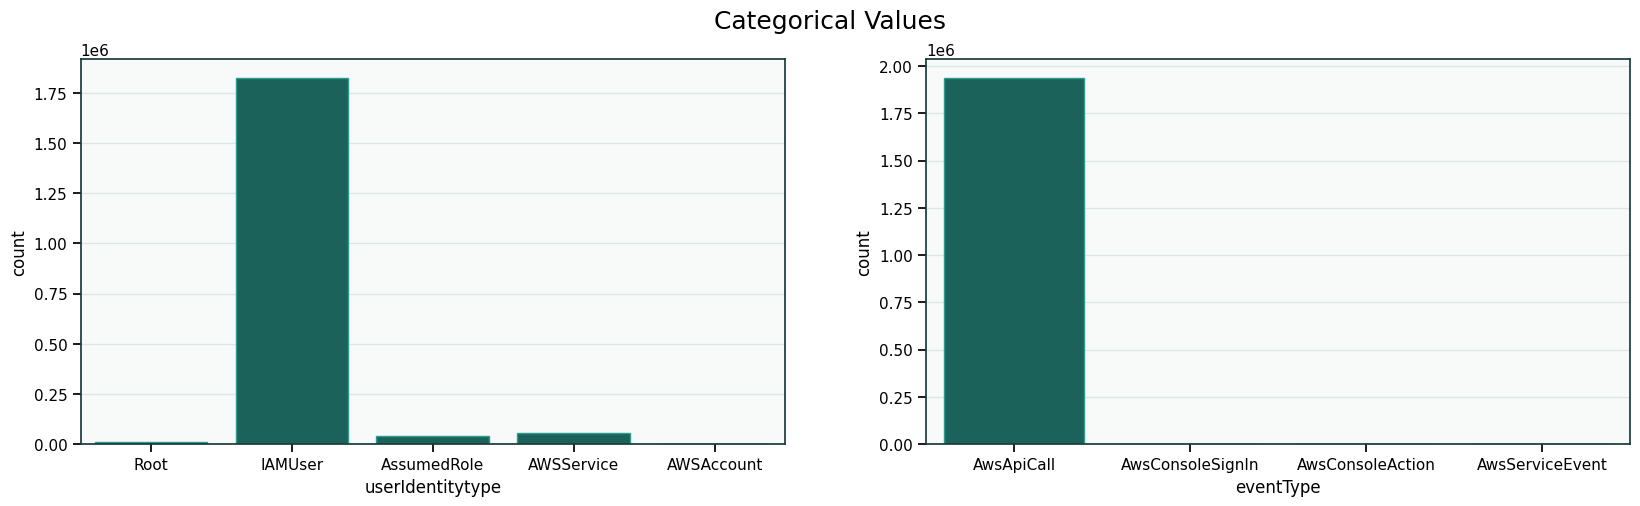

In [13]:
df_categorical_less_unique = ["userIdentitytype", "eventType"]

fig, axs = plt.subplots(ncols = len(df_categorical_less_unique), figsize=(20, 5))
for i, col in enumerate(df_categorical_less_unique):
    sns.countplot(df, x = col, ax=axs[i])
        

plt.suptitle("Categorical Values", fontsize = 18)


Text(0.5, 0.98, 'AWS Regions')

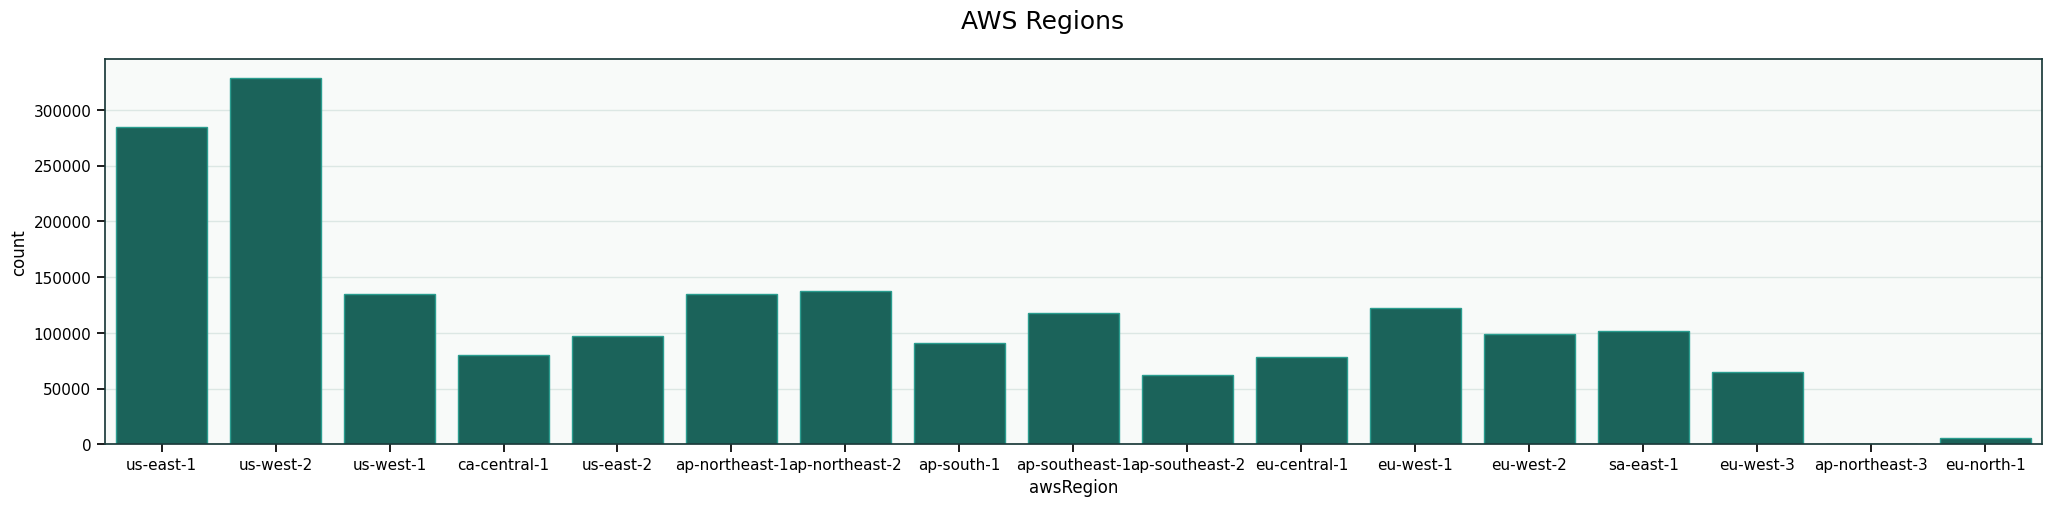

In [14]:
fig, axs = plt.subplots(ncols = 1, figsize=(25, 5))
sns.countplot(df, x = "awsRegion")

plt.suptitle("AWS Regions", fontsize = 18)

Text(0.5, 0.98, 'Top 10 Categories for each Category')

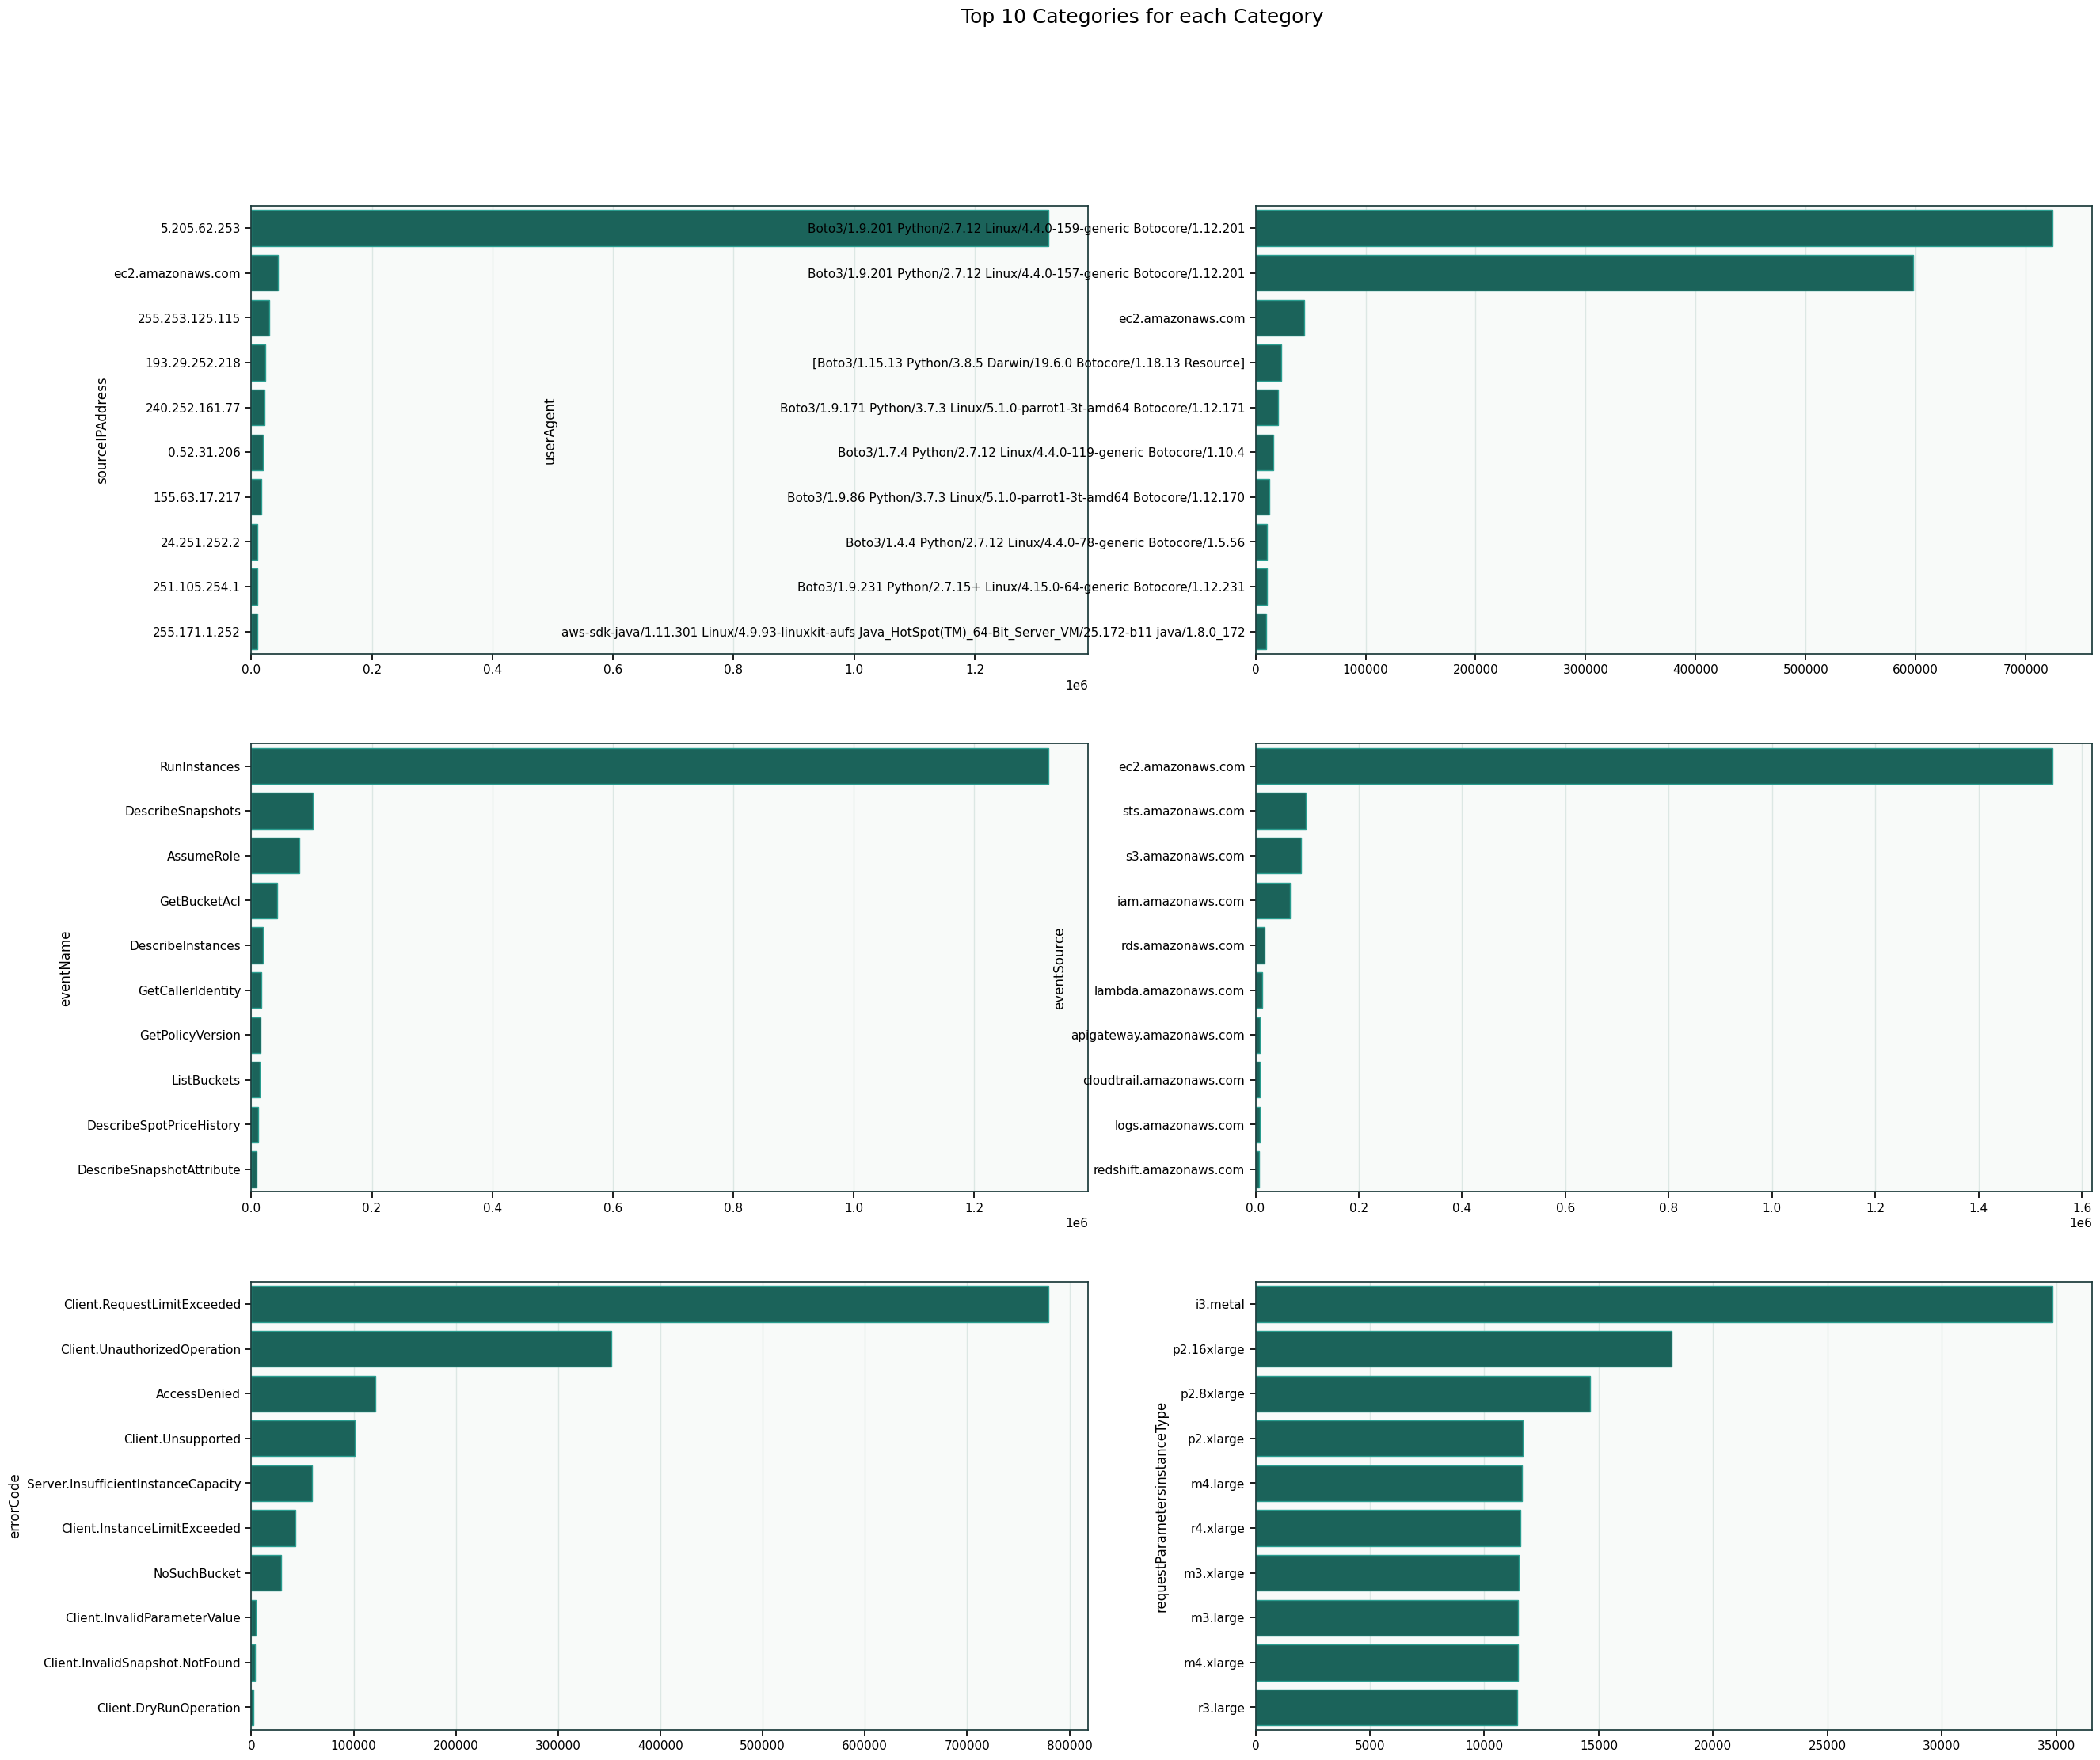

In [15]:
# optimize to only shoe top 10 categories within each category
top_n = 10
top_errors = [] # stop top 5 errors for sample feature engineering

df_categorical_optimized = df_categorical.drop(["userIdentitytype", "eventType", "awsRegion", "errorMessage"])
cols = round(len(df_categorical_optimized)/3)
rows = round(len(df_categorical_optimized)/cols)


fig, axs = plt.subplots(ncols = cols, nrows = rows, figsize=(30, 25))
axs = axs.flatten()

for i, col in enumerate(df_categorical_optimized):
    top_categories = df[col].value_counts().nlargest(top_n)
    sns.barplot(x=top_categories.values, y=top_categories.index, ax=axs[i])
    if col == "errorCode":
        top_errors = list(df[col].value_counts().nlargest(5).index)


plt.suptitle("Top 10 Categories for each Category", fontsize = 18)

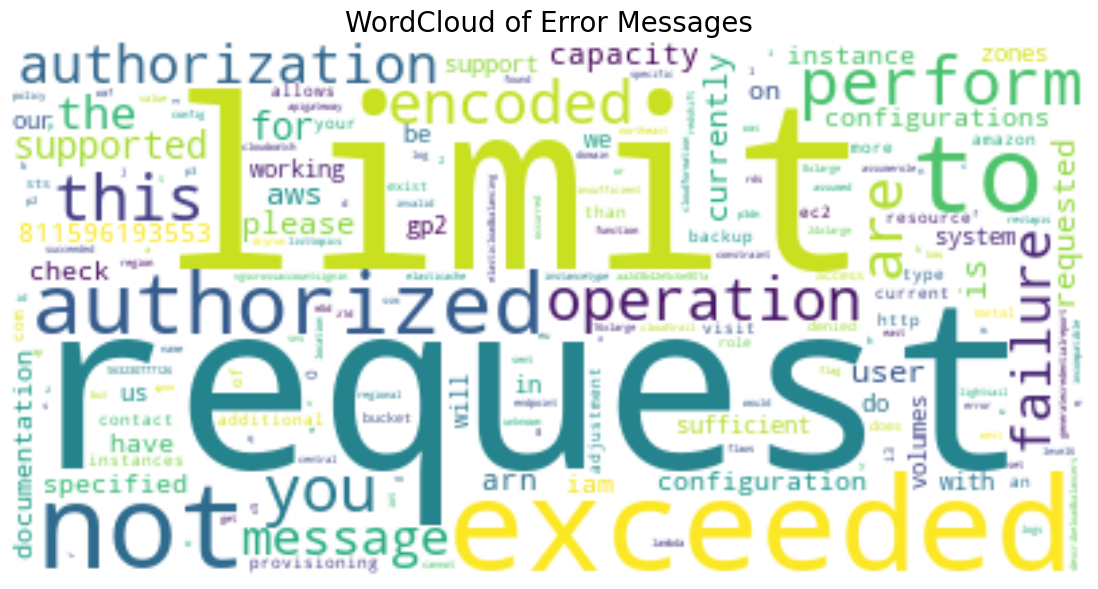

In [16]:
errors = df['errorMessage'].dropna().astype(str)
words = []
for msg in errors:
    words.extend(re.findall(r'\w+', msg.lower()))  # split words, lowercase

word_counts = Counter(words)
wc = WordCloud(background_color="white").generate_from_frequencies(word_counts)

plt.figure(figsize=(15, 7))
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.title("WordCloud of Error Messages", fontsize=20)
plt.show()

In [17]:
df

,eventTime,sourceIPAddress,userAgent,eventName,eventSource,awsRegion,eventVersion,userIdentitytype,eventType,errorCode,errorMessage,requestParametersinstanceType
0,2017-02-12 19:57:06+00:00,255.253.125.115,[S3Console/0.4],ListBuckets,s3.amazonaws.com,us-east-1,1.04,Root,AwsApiCall,NaN,NaN,NaN
1,2017-02-12 19:59:10+00:00,255.253.125.115,console.amazonaws.com,GetAccountPasswordPolicy,iam.amazonaws.com,us-east-1,1.02,Root,AwsApiCall,NoSuchEntityException,The Password Policy with domain name 811596193...,NaN
2,2017-02-12 19:59:10+00:00,255.253.125.115,console.amazonaws.com,GetAccountSummary,iam.amazonaws.com,us-east-1,1.02,Root,AwsApiCall,NaN,NaN,NaN
3,2017-02-12 19:59:10+00:00,255.253.125.115,console.amazonaws.com,ListAccountAliases,iam.amazonaws.com,us-east-1,1.02,Root,AwsApiCall,NaN,NaN,NaN
4,2017-02-12 19:59:10+00:00,255.253.125.115,console.amazonaws.com,ListMFADevices,iam.amazonaws.com,us-east-1,1.02,Root,AwsApiCall,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
1939202,2019-08-23 13:00:27+00:00,5.205.62.253,Boto3/1.9.201 Python/2.7.12 Linux/4.4.0-159-ge...,RunInstances,ec2.amazonaws.com,us-west-1,1.05,IAMUser,AwsApiCall,Client.RequestLimitExceeded,Request limit exceeded.,m5.12xlarge
1939203,2019-08-23 13:00:27+00:00,5.205.62.253,Boto3/1.9.201 Python/2.7.12 Linux/4.4.0-159-ge...,RunInstances,ec2.amazonaws.com,us-west-1,1.05,IAMUser,AwsApiCall,Client.RequestLimitExceeded,Request limit exceeded.,h1.2xlarge
1939204,2019-08-23 13:00:28+00:00,5.205.62.253,Boto3/1.9.201 Python/2.7.12 Linux/4.4.0-159-ge...,RunInstances,ec2.amazonaws.com,ap-northeast-2,1.05,IAMUser,AwsApiCall,Client.RequestLimitExceeded,Request limit exceeded.,r3.xlarge
1939205,2019-08-23 13:00:28+00:00,5.205.62.253,Boto3/1.9.201 Python/2.7.12 Linux/4.4.0-159-ge...,RunInstances,ec2.amazonaws.com,sa-east-1,1.05,IAMUser,AwsApiCall,Client.Unsupported,The requested configuration is currently not s...,c5d.xlarge


## Data Preprocesssing


In [18]:
# a sample of top errors are used to show pre-processing steps
top_errors

['Client.RequestLimitExceeded',
 'Client.UnauthorizedOperation',
 'AccessDenied',
 'Client.Unsupported',
 'Server.InsufficientInstanceCapacity']

In [19]:
# regex to replace common variables to aggregrate error messages (normalization)
df["errorMessage_grouped"] = (
    df["errorMessage"]
    .str.replace(r"sufficient\s+[a-z0-9\.]+\s+capacity", "sufficient <INSTANCE> capacity", regex=True)
    .str.replace(r"type\s+[^\s]+?\s+is not supported", "type <INSTANCE_TYPE> is not supported", regex=True)
    .str.replace(r"arn:aws:sts::\d+:assumed-role/[\w\-/]+", "<USER>", regex=True)
    .str.replace(r"arn:aws:iam::[0-9]+:user/[\w\-]+", "<USER>", regex=True)
    .str.replace(r"arn:aws:[\w-]+:[\w-]+:\d+:log-group:[\w\-/:\$]+", "<RESOURCE>", regex=True)
    .str.replace(r"<USER>:ec2-instance/i-[a-f0-9]+", "<USER>", regex=True)
    .str.replace(r"arn:aws:iam::[0-9]+:[\w/]+/[\w\-]+", "<RESOURCE>", regex=True)
    .str.replace(r"(Encoded authorization failure message: )[\w\-_]+", r"\1<ENCODED>", regex=True)
    .str.replace(r"\b\d+\b", "<ID>", regex=True)
    .str.replace(r"^You are not authorized to perform this operation.*$", "Permission Denied", regex=True)
)


In [20]:
# extract service from event source
df["service"] = df["eventSource"].apply(lambda x: re.findall(r'[a-z0-9]*\.',x)[0].strip(".").upper())

In [21]:
df

,eventTime,sourceIPAddress,userAgent,eventName,eventSource,awsRegion,eventVersion,userIdentitytype,eventType,errorCode,errorMessage,requestParametersinstanceType,errorMessage_grouped,service
0,2017-02-12 19:57:06+00:00,255.253.125.115,[S3Console/0.4],ListBuckets,s3.amazonaws.com,us-east-1,1.04,Root,AwsApiCall,NaN,NaN,NaN,NaN,S3
1,2017-02-12 19:59:10+00:00,255.253.125.115,console.amazonaws.com,GetAccountPasswordPolicy,iam.amazonaws.com,us-east-1,1.02,Root,AwsApiCall,NoSuchEntityException,The Password Policy with domain name 811596193...,NaN,The Password Policy with domain name <ID> cann...,IAM
2,2017-02-12 19:59:10+00:00,255.253.125.115,console.amazonaws.com,GetAccountSummary,iam.amazonaws.com,us-east-1,1.02,Root,AwsApiCall,NaN,NaN,NaN,NaN,IAM
3,2017-02-12 19:59:10+00:00,255.253.125.115,console.amazonaws.com,ListAccountAliases,iam.amazonaws.com,us-east-1,1.02,Root,AwsApiCall,NaN,NaN,NaN,NaN,IAM
4,2017-02-12 19:59:10+00:00,255.253.125.115,console.amazonaws.com,ListMFADevices,iam.amazonaws.com,us-east-1,1.02,Root,AwsApiCall,NaN,NaN,NaN,NaN,IAM
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1939202,2019-08-23 13:00:27+00:00,5.205.62.253,Boto3/1.9.201 Python/2.7.12 Linux/4.4.0-159-ge...,RunInstances,ec2.amazonaws.com,us-west-1,1.05,IAMUser,AwsApiCall,Client.RequestLimitExceeded,Request limit exceeded.,m5.12xlarge,Request limit exceeded.,EC2
1939203,2019-08-23 13:00:27+00:00,5.205.62.253,Boto3/1.9.201 Python/2.7.12 Linux/4.4.0-159-ge...,RunInstances,ec2.amazonaws.com,us-west-1,1.05,IAMUser,AwsApiCall,Client.RequestLimitExceeded,Request limit exceeded.,h1.2xlarge,Request limit exceeded.,EC2
1939204,2019-08-23 13:00:28+00:00,5.205.62.253,Boto3/1.9.201 Python/2.7.12 Linux/4.4.0-159-ge...,RunInstances,ec2.amazonaws.com,ap-northeast-2,1.05,IAMUser,AwsApiCall,Client.RequestLimitExceeded,Request limit exceeded.,r3.xlarge,Request limit exceeded.,EC2
1939205,2019-08-23 13:00:28+00:00,5.205.62.253,Boto3/1.9.201 Python/2.7.12 Linux/4.4.0-159-ge...,RunInstances,ec2.amazonaws.com,sa-east-1,1.05,IAMUser,AwsApiCall,Client.Unsupported,The requested configuration is currently not s...,c5d.xlarge,The requested configuration is currently not s...,EC2


In [22]:
df_errors = df.loc[df.errorCode.isin(top_errors), ["errorCode","errorMessage_grouped","service","awsRegion","eventName"]]\
            .groupby(["errorCode","errorMessage_grouped","service"])\
            .agg(eventNames = ("eventName", lambda x: ", ".join(x.unique()))\
                 ,counts=("errorCode", "size"))\
            .reset_index()

In [23]:
pd.set_option("display.max_colwidth", None)  # show full content in each cell


In [24]:
df_errors

errorCode  \
0                            AccessDenied   
1                            AccessDenied   
2                            AccessDenied   
3                            AccessDenied   
4                            AccessDenied   
...                                   ...   
1813         Client.UnauthorizedOperation   
1814                   Client.Unsupported   
1815                   Client.Unsupported   
1816  Server.InsufficientInstanceCapacity   
1817  Server.InsufficientInstanceCapacity   

                                                                                                                                                                                                                  errorMessage_grouped  \
0                                                                                                                                                                                                                        Access Denied   
1                                                                                                                                                                                  Account: <ID> is not currently delegated by AWS FM.   
2                                                                                                                                                                                                            An unknown error occurred   
3                                                                                                                                                                                                            An unknown error occurred   
4                                                                                                                                                                                                            An unknown error occurred   
...                                                                                                                                                                                                                                ...   
1813                                                                                                                                                                                                                 Permission Denied   
1814                                                                                                              The requested configuration is currently not supported. Please check the documentation for supported configurations.   
1815  Your requested instance type <INSTANCE_TYPE> is not supported in your requested Availability Zone (us-west-2d). Please retry your request by not specifying an Availability Zone or choosing us-west-2c, us-west-2b, us-west-2a.   
1816                                                                                                                                                                                                            Insufficient capacity.   
1817                                                                  We currently do not have sufficient <INSTANCE> capacity in zones with support for 'gp2' volumes. Our system will be working on provisioning additional capacity.   

               service  \
0                   S3   
1                  FMS   
2     ELASTICBEANSTALK   
3                 GLUE   
4             OPSWORKS   
...                ...   
1813               EC2   
1814               EC2   
1815               EC2   
1816               EC2   
1817               EC2   

                                                                                                                                                                                                                                                                                                                                                                                 

In [24]:
# filter error messages that is more than 1000 count
df_errors = df_errors[df_errors["counts"] > 1000]


In [25]:
# tokenize text by capital letters if the combined event names is too many
# then find the top 3 events that occur the most
# this is to ensure the token for input fine-tuning is less
df_errors.loc[df_errors["eventNames"].str.len() > 500, "eventNames"] = (df_errors.loc[df_errors["eventNames"].str.len() > 500, "eventNames"]
    .apply(lambda x: "" + Counter(re.findall(r'[A-Z][a-z]*', x)).most_common(1)[0][0] + ", " 
           + Counter(re.findall(r'[A-Z][a-z]*', x)).most_common(2)[1][0] + " and "
           + Counter(re.findall(r'[A-Z][a-z]*', x)).most_common(3)[2][0]+ " Operations")
)

In [26]:
df_errors

,errorCode,errorMessage_grouped,service,eventNames,counts
0,AccessDenied,Access Denied,S3,"Bucket, Get and Put Operations",34914
11,AccessDenied,Not authorized to perform sts:AssumeRole,STS,AssumeRole,6302
168,AccessDenied,User: <USER> is not authorized to perform: apigateway:GET on resource: arn:aws:apigateway:us-west-<ID>::/restapis,APIGATEWAY,GetRestApis,1116
420,AccessDenied,User: <USER> is not authorized to perform: config:DescribeConfigurationRecorderStatus,CONFIG,DescribeConfigurationRecorderStatus,1033
651,AccessDenied,User: <USER> is not authorized to perform: elasticloadbalancing:DescribeLoadBalancers,ELASTICLOADBALANCING,DescribeLoadBalancers,1649
799,AccessDenied,User: <USER> is not authorized to perform: iam:GenerateCredentialReport on resource: *,IAM,GenerateCredentialReport,2434
1311,AccessDenied,User: <USER> is not authorized to perform: rds:DescribeDBInstances,RDS,DescribeDBInstances,1023
1643,AccessDenied,User: <USER> is not authorized to perform: sts:AssumeRole on resource: <RESOURCE>,STS,AssumeRole,10529
1812,Client.RequestLimitExceeded,Request limit exceeded.,EC2,"RunInstances, DescribeSnapshotAttribute, CreateDefaultVpc",779330
1813,Client.UnauthorizedOperation,Permission Denied,EC2,"Describe, Get and Instances Operations",351760


In [27]:
fine_tune = pd.DataFrame()
fine_tune = df_errors.copy()

In [ ]:
fine_tune["output"] = "1. Explanations 2. Common Cause 3. Suggested Solutions" 
# sample of output structuring, but need real examples that will be done during modelling stage

In [29]:
fine_tune.sort_values(by = "counts", ascending=False).reset_index(drop=True)

,errorCode,errorMessage_grouped,service,eventNames,counts,output
0,Client.RequestLimitExceeded,Request limit exceeded.,EC2,"RunInstances, DescribeSnapshotAttribute, CreateDefaultVpc",779330,1. Explanations 2. Common Cause 3. Suggested Solutions
1,Client.UnauthorizedOperation,Permission Denied,EC2,"Describe, Get and Instances Operations",351760,1. Explanations 2. Common Cause 3. Suggested Solutions
2,Client.Unsupported,The requested configuration is currently not supported. Please check the documentation for supported configurations.,EC2,RunInstances,101220,1. Explanations 2. Common Cause 3. Suggested Solutions
3,Server.InsufficientInstanceCapacity,We currently do not have sufficient <INSTANCE> capacity in zones with support for 'gp2' volumes. Our system will be working on provisioning additional capacity.,EC2,RunInstances,51183,1. Explanations 2. Common Cause 3. Suggested Solutions
4,AccessDenied,Access Denied,S3,"Bucket, Get and Put Operations",34914,1. Explanations 2. Common Cause 3. Suggested Solutions
5,AccessDenied,User: <USER> is not authorized to perform: sts:AssumeRole on resource: <RESOURCE>,STS,AssumeRole,10529,1. Explanations 2. Common Cause 3. Suggested Solutions
6,Server.InsufficientInstanceCapacity,Insufficient capacity.,EC2,RunInstances,8140,1. Explanations 2. Common Cause 3. Suggested Solutions
7,AccessDenied,Not authorized to perform sts:AssumeRole,STS,AssumeRole,6302,1. Explanations 2. Common Cause 3. Suggested Solutions
8,AccessDenied,User: <USER> is not authorized to perform: iam:GenerateCredentialReport on resource: *,IAM,GenerateCredentialReport,2434,1. Explanations 2. Common Cause 3. Suggested Solutions
9,AccessDenied,User: <USER> is not authorized to perform: elasticloadbalancing:DescribeLoadBalancers,ELASTICLOADBALANCING,DescribeLoadBalancers,1649,1. Explanations 2. Common Cause 3. Suggested Solutions


In [30]:
fine_tune.to_json("fine_tune.json", orient="records")